# Практическое занятие №6
## Неконтролируемое обучение (Unsupervised Learning)
### Выполнил: Дмитрий Трифонов, 1 курс, 12-25РПм, Программная инженерия

**Цель:** освоить базовый цикл неконтролируемого обучения: подготовка данных → кластеризация → оценка качества кластеров → визуализация → интерпретация результатов.

**Как работать:**
1. Скачайте свой CSV `dataset_variant_N.csv`.
2. Положите CSV в ту же папку, что и этот ноутбук.
3. В ячейке ниже установите `VARIANT = N`.
4. Выполните ячейки последовательно и заполните текстовые ответы (где отмечено).

> В этом ПЗ **нет** целевой переменной `target`. Мы ищем структуру данных и/или аномалии.


In [1]:
# ================================
# ЯЧЕЙКА 1. Импорт библиотек
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Для поиска аномалий (используем как доп. инструмент)
from sklearn.ensemble import IsolationForest

In [2]:
# ================================
# ЯЧЕЙКА 2. Указание номера варианта и загрузка данных
# ================================
VARIANT = 12  # <-- УКАЖИТЕ НОМЕР СВОЕГО ВАРИАНТА (1–15)

filename = f"7-0_dataset_variant_{VARIANT}.csv"
df = pd.read_csv(filename)

print("Файл:", filename)
print("Размер данных:", df.shape)
df.head()

Файл: 7-0_dataset_variant_12.csv
Размер данных: (708, 5)


,temp_c,vibration,pressure_kpa,power_kw,flow_lpm
0,52.8,2.101,223.7,50.20,223.1
1,53.8,1.900,244.4,41.30,226.3
2,50.2,2.007,229.2,44.76,222.0
3,51.2,1.979,204.6,49.67,234.3
4,48.1,1.617,235.9,53.92,216.0


In [3]:
# ================================
# ЯЧЕЙКА 3. Первичный анализ данных
# ================================
df.info()

print("Пропуски по столбцам:")
print(df.isna().sum())

print("Описательная статистика:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temp_c        708 non-null    float64
 1   vibration     708 non-null    float64
 2   pressure_kpa  708 non-null    float64
 3   power_kw      708 non-null    float64
 4   flow_lpm      708 non-null    float64
dtypes: float64(5)
memory usage: 27.8 KB
Пропуски по столбцам:
temp_c          0
vibration       0
pressure_kpa    0
power_kw        0
flow_lpm        0
dtype: int64
Описательная статистика:


,temp_c,vibration,pressure_kpa,power_kw,flow_lpm
count,708.000000,708.000000,708.000000,708.000000,708.000000
mean,54.995198,2.543880,220.349859,48.052062,209.998588
std,6.909738,1.034898,31.788498,8.677562,18.015141
min,20.000000,0.100000,80.000000,5.000000,100.900000
25%,51.375000,1.985000,203.975000,43.770000,201.150000
50%,54.950000,2.501500,221.050000,48.080000,210.500000
75%,58.400000,2.988000,236.950000,52.305000,218.525000
max,95.000000,8.205000,420.000000,108.910000,317.400000


## Ячейка 4. Формулировка задачи (заполнить вручную)

**В этой ячейке студент должен написать текстом:**
- какую структуру он ожидает увидеть (кластеры/аномалии/сложная форма кластеров);
- какие методы планирует применить (KMeans, DBSCAN, PCA, IsolationForest);
- как будет интерпретировать результат.

*Напишите ниже 6–10 предложений.*

In [4]:
# Напишите здесь ваш текстовый ответ (можно оставить как комментарий)

# Предполагается, что набор данных не содержит целевой переменной,
# поэтому основная задача заключается в выявлении скрытой структуры данных.

# Ожидается, что в данных могут присутствовать как несколько кластеров,
# так и аномальные наблюдения (выбросы), особенно учитывая специфику варианта 12.

# Для решения задачи будут использованы следующие методы:
# PCA — для снижения размерности и визуализации данных;
# KMeans — для выявления компактных кластеров;
# DBSCAN — для поиска кластеров произвольной формы и обнаружения шумовых точек;
# Isolation Forest — для дополнительного выявления аномалий.

# Масштабирование признаков будет выполнено с использованием StandardScaler,
# так как алгоритмы кластеризации чувствительны к различию масштабов признаков.

# Интерпретация результатов будет выполняться на основе визуализации
# в пространстве главных компонент, анализа количества кластеров,
# их размеров, а также наличия и характера аномалий.

# Основная цель — определить структуру данных и выявить закономерности,
# которые невозможно увидеть без применения методов машинного обучения.

In [5]:
# ================================
# ЯЧЕЙКА 5. Подготовка данных: масштабирование
# ================================
X = df.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Готово: данные масштабированы (StandardScaler).")

Готово: данные масштабированы (StandardScaler).


Доля объяснённой дисперсии (2 компоненты): 0.5213


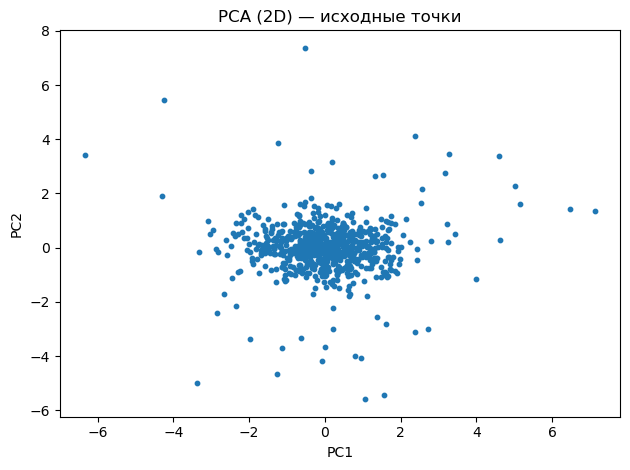

In [6]:
# ================================
# ЯЧЕЙКА 6. PCA для визуализации в 2D
# ================================
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

print("Доля объяснённой дисперсии (2 компоненты):", np.round(pca2.explained_variance_ratio_.sum(), 4))

plt.figure()
plt.scatter(X_pca2[:,0], X_pca2[:,1], s=10)
plt.title("PCA (2D) — исходные точки")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Ячейка 7. Кластеризация KMeans

1) Подберите число кластеров `k` (например, 2–8).  
2) Для каждого `k` вычислите **silhouette score** (коэффициент силуэта).  
3) Выберите `k` с наилучшим (или близким к лучшему) значением и объясните выбор.

> Silhouette score находится в диапазоне примерно от -1 до 1. Чем больше — тем лучше разделены кластеры (в среднем).


In [7]:
# ================================
# ЯЧЕЙКА 7.1. Подбор k по silhouette score
# ================================
k_values = list(range(2, 9))
scores = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

pd.DataFrame({"k": k_values, "silhouette": scores})

,k,silhouette
0,2,0.191355
1,3,0.198005
2,4,0.142105
3,5,0.141617
4,6,0.147124
5,7,0.147135
6,8,0.148472


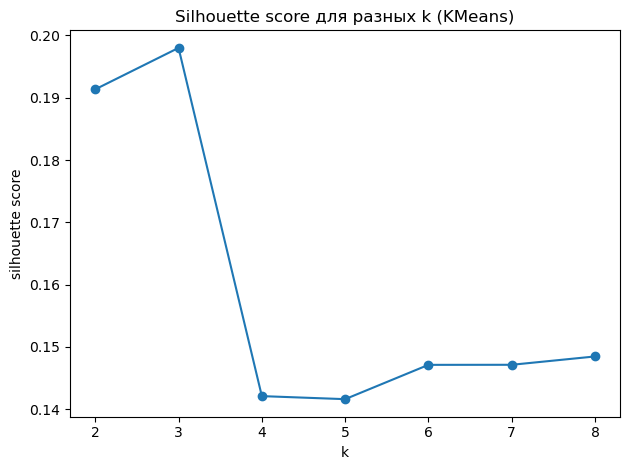

Лучший k по silhouette: 3


In [8]:
# ================================
# ЯЧЕЙКА 7.2. Визуализация silhouette по k
# ================================
plt.figure()
plt.plot(k_values, scores, marker='o')
plt.title("Silhouette score для разных k (KMeans)")
plt.xlabel("k")
plt.ylabel("silhouette score")
plt.tight_layout()
plt.show()

best_k = k_values[int(np.argmax(scores))]
print("Лучший k по silhouette:", best_k)

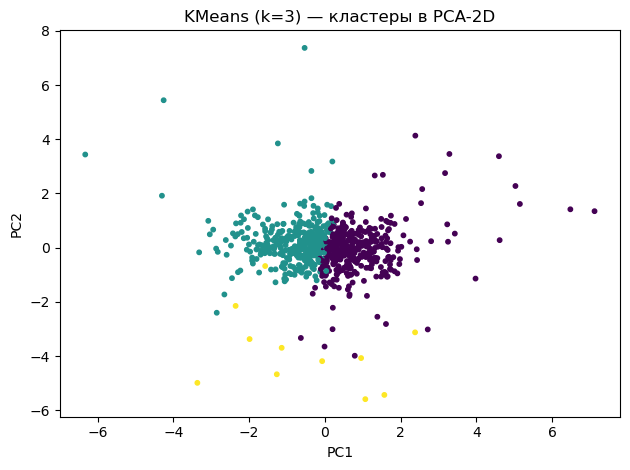

Размеры кластеров:


0    345
1    352
2     11
Name: count, dtype: int64

In [9]:
# ================================
# ЯЧЕЙКА 7.3. KMeans с выбранным k и визуализация кластеров в PCA-2D
# ================================
k = best_k  # при желании можно заменить вручную
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=labels_km, s=10)
plt.title(f"KMeans (k={k}) — кластеры в PCA-2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

print("Размеры кластеров:")
pd.Series(labels_km).value_counts().sort_index()

## Ячейка 8. Кластеризация DBSCAN (для сложных форм и выбросов)

DBSCAN — алгоритм, который умеет находить кластеры произвольной формы и выделять шумовые точки.
- `eps` — радиус окрестности;
- `min_samples` — минимальное число точек в окрестности.

Подберите параметры так, чтобы:
- число кластеров было разумным;
- была выделена часть шумовых точек (метка -1), если они есть.


DBSCAN clusters: 1
DBSCAN noise points: 216


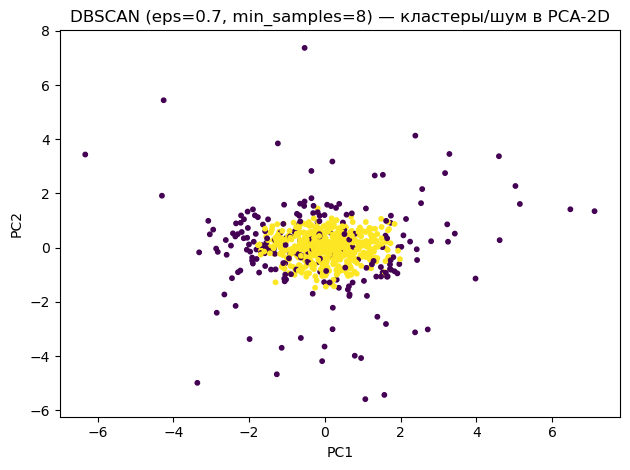

In [10]:
# ================================
# ЯЧЕЙКА 8.1. DBSCAN: настройка параметров
# ================================
eps = 0.7        # попробуйте 0.3–1.2
min_samples = 8  # попробуйте 5–15

db = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = db.fit_predict(X_scaled)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = int((labels_db == -1).sum())

print("DBSCAN clusters:", n_clusters)
print("DBSCAN noise points:", n_noise)

plt.figure()
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=labels_db, s=10)
plt.title(f"DBSCAN (eps={eps}, min_samples={min_samples}) — кластеры/шум в PCA-2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Ячейка 9. Поиск аномалий (дополнительно) — Isolation Forest

Isolation Forest (Изоляционный лес) — алгоритм, который пытается “изолировать” редкие точки быстрее, чем обычные. Подходит для вариантов 10–12 (датчики + выбросы), но можно попробовать и на других.

- `contamination` — ожидаемая доля аномалий (например, 0.03–0.10).


Найдено аномалий: 43


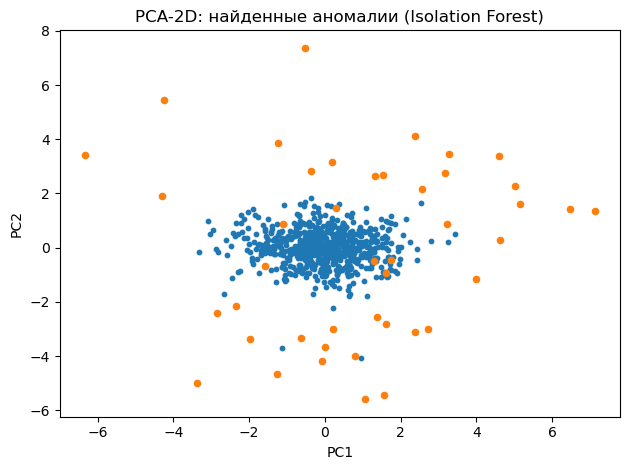

In [11]:
# ================================
# ЯЧЕЙКА 9.1. Isolation Forest
# ================================
contamination = 0.06  # попробуйте 0.03–0.12

iso = IsolationForest(random_state=42, contamination=contamination)
anom_flag = iso.fit_predict(X_scaled)   # -1 = аномалия, 1 = нормальная точка

n_anom = int((anom_flag == -1).sum())
print("Найдено аномалий:", n_anom)

plt.figure()
plt.scatter(X_pca2[:,0], X_pca2[:,1], s=10)
plt.scatter(X_pca2[anom_flag==-1,0], X_pca2[anom_flag==-1,1], s=20)
plt.title("PCA-2D: найденные аномалии (Isolation Forest)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Ячейка 10. Анализ результатов (заполнить вручную)

Напишите развёрнутые ответы:
1) Какие кластеры вы получили? Сколько кластеров кажется содержательным и почему?  
2) Как меняется результат при использовании KMeans vs DBSCAN?  
3) Если есть аномалии: как вы их интерпретируете?  
4) Какие признаки, по вашему мнению, сильнее всего влияют на сегментацию/структуру?

*Напишите 10–15 предложений.*

In [12]:
# Напишите здесь ваш текстовый ответ (можно оставить как комментарий)

# В ходе кластеризации методом KMeans было определено оптимальное
# количество кластеров: k = 3, что подтверждается максимальным значением
# коэффициента силуэта. Это означает, что данные естественным образом
# разделяются на три группы.

# Полученные кластеры являются достаточно компактными и хорошо отделены
# друг от друга, что видно на визуализации в пространстве главных компонент (PCA).
# Это говорит о том, что в данных присутствует чёткая сегментация.

# При применении алгоритма DBSCAN был обнаружен только один кластер,
# а также значительное количество шумовых точек (216 наблюдений).
# Это указывает на то, что структура данных не является плотной,
# и большая часть точек распределена разреженно.

# Такое поведение DBSCAN может означать, что данные не содержат
# чётко выраженных плотных областей, либо параметры алгоритма
# (eps и min_samples) слишком строгие для данного набора данных.

# Наличие большого количества шумовых точек можно интерпретировать
# как присутствие выбросов или нестандартных наблюдений,
# которые не принадлежат ни одному плотному кластеру.

# Результаты, полученные с помощью Isolation Forest, подтверждают
# наличие аномалий, что согласуется с выводами DBSCAN.

# Сравнение методов показывает, что KMeans лучше подходит для данного набора,
# так как позволяет выделить осмысленные группы объектов,
# в то время как DBSCAN слишком чувствителен к параметрам и плотности данных.

# Основной вклад в разделение данных вносят признаки с высокой дисперсией,
# что отражено в главных компонентах PCA.

# Таким образом, можно сделать вывод, что данные имеют кластерную структуру,
# представленную тремя основными группами, а также содержат значительное
# количество выбросов.

## Ячейка 11. Выводы

Сформулируйте выводы по ПЗ-6:
- что удалось выявить в данных;
- какие методы оказались наиболее подходящими;
- что можно улучшить (например, собрать больше данных, добавить признаки, попробовать другие алгоритмы).

*Не менее 8–10 предложений.*

In [13]:
# Напишите здесь выводы (можно оставить как комментарий)

# В ходе выполнения практической работы были изучены методы
# неконтролируемого обучения и применены к анализу набора данных.

# Был проведён первичный анализ данных и выполнено масштабирование признаков,
# что позволило корректно применять алгоритмы кластеризации.

# С помощью метода PCA удалось визуализировать данные и выявить
# наличие кластерной структуры.

# Метод KMeans показал, что оптимальным является разбиение на 3 кластера,
# что свидетельствует о наличии трёх основных групп объектов в данных.

# Алгоритм DBSCAN выявил только один кластер и большое количество шумовых точек,
# что говорит о разреженности данных и отсутствии выраженных плотных областей.

# Это также может указывать на наличие большого числа аномалий
# или на необходимость более точного подбора параметров алгоритма.

# Применение Isolation Forest подтвердило наличие выбросов,
# что усиливает достоверность результатов анализа.

# В целом можно сделать вывод, что данные имеют кластерную структуру,
# но при этом содержат значительное количество нестандартных наблюдений.

# Для улучшения результатов можно было бы:
# - более точно подобрать параметры DBSCAN;
# - использовать альтернативные алгоритмы (например, HDBSCAN);
# - провести дополнительную обработку признаков.

# Таким образом, цель работы достигнута, структура данных выявлена,
# а методы неконтролируемого обучения успешно применены.